In [1]:
from helpers import *

import os
import re
import numpy as np
import matplotlib. pyplot as plt
from scipy.spatial.distance import directed_hausdorff

In [2]:
nubmer_points_list= [100, 200,300,400,500,600,700,800,900,1000,1100,1200, 1300,1400,1500]
n_runs= [10]

In [7]:
def calculate_distance(point1, point2):
    return sum((x - y) ** 2 for x, y in zip(point1, point2)) ** 0.5

def calculate_tolerance(points):
    num_points = len(points)
    tolerance = 1/num_points
    return tolerance
    
def count_repeated_points(points):
    #points = points[np.lexsort((points[:, 1], points[:, 0]))]
    n= len(points)
    ep=  calculate_tolerance(points)
    distinct_points = []

    for point in points:
        is_distinct = True
        for distinct_point in distinct_points:
            if calculate_distance(point, distinct_point) < ep:
                is_distinct = False
                break
        if is_distinct:
            distinct_points.append(point)
            
    return len(distinct_points), distinct_points

In [8]:
import os

def list_txt_files_in_directory(directory_path):
    files_and_directories = os.listdir(directory_path)
    txt_files = [file for file in files_and_directories if file.endswith('.txt')]
    txt_files = [file for file in txt_files if '.txt' in file]
    txt_files.sort()
    txt_files= [directory_path+"/"+file for file in txt_files]
        
    return txt_files

In [9]:
eps_t= 1e-5
def get_accuracy(setXYP):
    acc= 0.0
    for i in range(len(setXYP)):
        if (0.5 <= setXYP[i][0] <=1.0 and (1-setXYP[i][0]-setXYP[i][1])<eps_t)== True:
            acc+= 1
    return (acc/len(setXYP))*100

In [10]:
n_times= 10
def get_values(folders):
    dist_= []
    avg_hd= []
    accuracy_list= []
    for pt in range(len(nubmer_points_list)):
        directory_path = folders[pt]

        files= list_txt_files_in_directory(directory_path)
        if len(files)>n_times:
            files= files[:n_times]
        res= []
        hd= []
        
        num_points= nubmer_points_list[pt]

        
        res_solns= []
        for file in files:
            
            if "._" in file:
                    file= file.replace("._","")
            
            solns= np.genfromtxt(file, delimiter=',')
            res_solns.extend(solns.tolist())

        res_solns= np.array(res_solns)
        num, distinct_points= count_repeated_points(res_solns)
        distinct_points= np.array(distinct_points)
        
        # Get PDP
        
        dist_.append((len(distinct_points)/(len(res_solns)))*100)
        
        # Get HD:
        t_values = np.random.uniform(9.0, 10, len(distinct_points)-1)

        points = np.column_stack((t_values, 15 - t_values))
        points= np.vstack((points, np.array([5.0,9.0])))
        

        print(len(distinct_points), len(res_solns))
        hausdorff_distance = directed_hausdorff(distinct_points, points)[0]
        avg_hd.append(hausdorff_distance)
        accuracy_list.append(get_accuracy(distinct_points))
        
    # Create subplots with different scales
    fig, ax1 = plt.subplots(figsize=(8, 4))

    # Create second axis with different scale
    ax1.set_xlabel('Number of starting points')
    ax1.set_ylim([0.0, np.max(dist_)])
    ax1.plot(nubmer_points_list, dist_, 'bo-')    
    ax1.set_ylabel('Perentage of distint points',color='blue')
    ax2 = ax1.twinx()
    ax2.spines['right'].set_position(('outward', 60))
    ax2.plot(nubmer_points_list, avg_hd, 'go-')
    ax2.set_ylabel('Hausdorff Distance', color='g')
    ax2.set_ylim([0.0, np.max(avg_hd)])

    xticks = nubmer_points_list
    ax1.set_xticks(xticks)
    ax1.set_xticklabels([f'{tick:.0f}' for tick in xticks])
    #plt.savefig('../GSM/solns_runs/Ex1/plot_ex1.png')
    plt.grid(True)
    plt.show()

    return dist_,avg_hd,accuracy_list

In [11]:
def plot_solns(folders):
    all_solns= []
    for pt in range(len(nubmer_points_list)):
        directory_path = folders[pt]

        files= list_txt_files_in_directory(directory_path)
        res= []
        for file in files:
            solns= np.genfromtxt(file, delimiter=',')
            res.extend(solns.tolist())
    
        res= np.array(res)
        num, distinct_points= count_repeated_points(res)
            
        all_solns.append(distinct_points)
        
    
    
    for i in range(len(all_solns)):
        print("Plot for {} points".format(nubmer_points_list[i]))
        plt.scatter(np.array(all_solns[i])[:,0], np.array(all_solns[i])[:,1], c= 'black')
        plt.xlim([0,10])
        plt.ylim([0,10])
        plt.grid(True)
        plt.show()

In [12]:
def plot_solns(folders):
    all_solns= []
    for pt in range(len(nubmer_points_list)):
        directory_path = folders[pt]

        files= list_txt_files_in_directory(directory_path)
        res= []
        for file in files:
            solns= np.genfromtxt(file, delimiter=',')
#             num, distinct_points,_ = count_repeated_points(solns)
#             distinct_points= np.array(distinct_points)
            res.extend(solns.tolist())
    
        res= np.array(res)
        num, distinct_points= count_repeated_points(res)
#         distinct_points= np.array(distinct_points)
            
        all_solns.append(distinct_points)
    return all_solns


# EIA

In [13]:
def extract_number(s):
    return int(re.search(r'\d+', s).group())

def list_subfolders(folder_path):
    subfolders = [f.path for f in os.scandir(folder_path) if f.is_dir()]
    sorted_subfolders = sorted(subfolders, key=lambda x: int(x.split("_")[-1]))
    return sorted_subfolders


def list_txt_files(folder_path):
    txt_files = [f for f in os.listdir(folder_path) if f.endswith('.txt')]
#     txt_files = sorted(txt_files, key=lambda x: int(x.split("_")[2]))
    return txt_files

## Number of starting points vs. PDP and HD

In [14]:
n_times= 10
def get_values(folders):
    dist_= []
    avg_hd= []
    accuracy_list= []
    for pt in range(len(nubmer_points_list)):
        directory_path = folders[pt]
        #print(directory_path)

        files= list_txt_files_in_directory(directory_path)
        
        files= files[:n_times]
        res= []
        hd= []
        
        num_points= nubmer_points_list[pt]

#         t_values = np.random.uniform(0.5, 1, num_points)

#         points = np.column_stack((t_values, 1 - t_values))
        
        res_solns= []

        for file in files:
            
            if "._" in file:
                    file= file.replace("._","")
            
            solns= np.genfromtxt(file, delimiter=',') #[:,:-1]
            
            res_solns.extend(solns.tolist())
            
#             num, distinct_points,_ = count_repeated_points(solns)
#             distinct_points= np.array(distinct_points)
                        
#             res_solns.extend(distinct_points.tolist())
        
        
        res_solns= np.array(res_solns)
        num, distinct_points= count_repeated_points(res_solns)
        distinct_points= np.array(distinct_points)
        
        # Get PDP
        
        dist_.append((len(distinct_points)/(len(res_solns)))*100)
        
        print(len(distinct_points), len(res_solns))
        
        # Get HD:
        t_values = np.random.uniform(0.5, 1, len(distinct_points))

        points = np.column_stack((t_values, 1 - t_values))
        

#         print(points.shape, distinct_points.shape)
        hausdorff_distance = directed_hausdorff(distinct_points, points)[0]
        avg_hd.append(hausdorff_distance)
        accuracy_list.append(get_accuracy(distinct_points))
        
    # Create subplots with different scales
    fig, ax1 = plt.subplots(figsize=(8, 4))

    # Create second axis with different scale
    ax1.set_xlabel('Number of starting points')
#     ax2 = ax1.twinx()
    ax1.set_ylim([0.0, np.max(dist_)])
    ax1.plot(nubmer_points_list, dist_, 'bo-')
    
#     ax1.set_yticks(dist_)
    
    ax1.set_ylabel('Perentage of distint points',color='blue')
#     ax1.set_ylabel('Perentage of distint points', color='b')


    # Create third axis with different scale
    ax2 = ax1.twinx()
    ax2.spines['right'].set_position(('outward', 60))  # Move the spine to the right
    ax2.plot(nubmer_points_list, avg_hd, 'go-')
    ax2.set_ylabel('Hausdorff Distance', color='g')
    ax2.set_ylim([0.0, np.max(avg_hd)])

    xticks = nubmer_points_list  # Precisely specify xticks from 0 to 10 with a step of 1
    ax1.set_xticks(xticks)
    ax1.set_xticklabels([f'{tick:.0f}' for tick in xticks])  # Format labels as strings with one decimal place


#     plt.savefig('./plots/Metrics/Ex1/ex1_gsm.jpeg')
    #plt.savefig('../EIA/solns_runs/Ex1/plot_ex1.png')
# plt.xticks(list(range(len(possible_num_points))),possible_num_points)
    plt.grid(True)
    plt.show()

        
    return dist_,avg_hd,accuracy_list

In [15]:
percents= [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

Running for p=  100
1000 1000
2000 2000
3000 3000
4000 4000
5000 5000
6000 6000
7000 7000
8000 8000
9000 9000
10000 10000
11000 11000
12000 12000
13000 13000
14000 14000
15000 15000


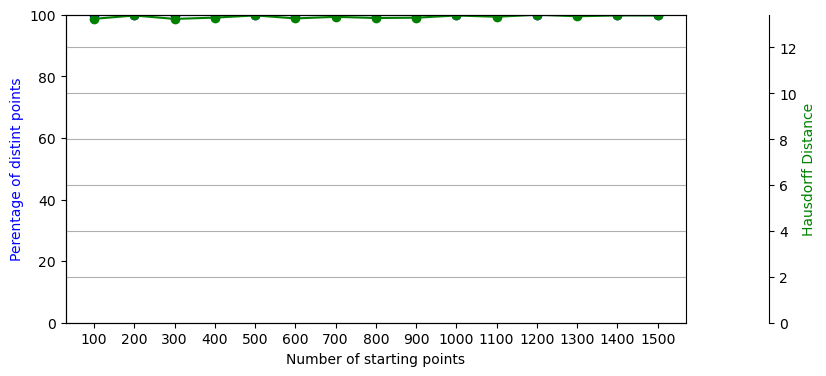

Running for p=  90
991 1000
1997 2000
2986 3000
3987 4000
4989 5000
5983 6000
6982 7000
7988 8000
8978 9000
9977 10000
10985 11000
11963 12000
12967 13000
13982 14000
14977 15000


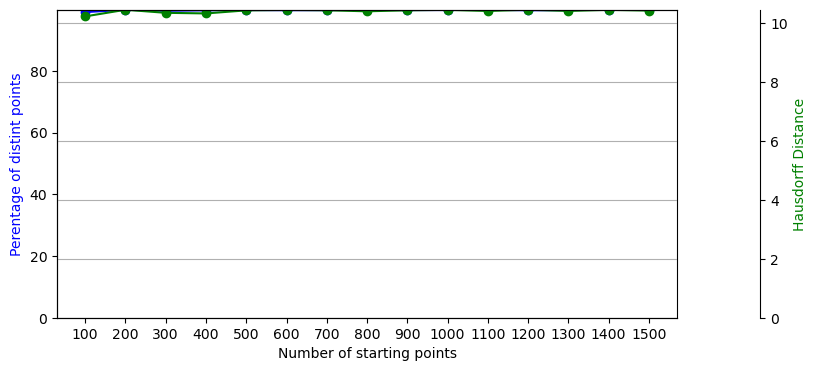

Running for p=  80
985 1000
1973 2000
2980 3000
3986 4000
4974 5000
5974 6000
6966 7000
7976 8000
8961 9000
9975 10000
10947 11000
11957 12000
12952 13000


In [16]:
Ex4Res= {10: {
    "pdp": None, "hd": None,
}, 20: {
    "pdp": None, "hd":None,
}, 30: {
    "pdp": None, "hd": None, 
}, 40: {
    "pdp": None, "hd": None, 
}
, 50: {
    "pdp": None, "hd": None, 
}
, 60: {
    "pdp": None, "hd": None, 
}
, 70: {
    "pdp": None, "hd": None, 
}
, 80: {
    "pdp": None, "hd": None, 
}
, 90: {
    "pdp": None, "hd": None, 
}
, 100: {
    "pdp": None, "hd": None, 
}
}

# for p in range(len(percents)):
for p in range(len(percents)-1, -1, -1):
    print("Running for p= ", percents[p])
    main_path = "./percent/"+str(percents[p])+"/Ex4/"
    subfolders = list_subfolders(main_path)

        
    txt_files = list_subfolders(subfolders[0])
    # list_txt_files(subfolders[0])

    titles = [str(100*i) for i in range(1, 16)]

    colors = [
        'blue', 'orange', 'r', 'yellow', 'purple',
        'brown', 'pink', 'gray', 'olive', 'cyan', 'red',
        'lightcoral', 'darkgoldenrod', 'mediumseagreen', 'green', 'mangeta'
    ]

    folders= ["./percent/"+str(percents[p])+"/Ex4/N_{}/".format(str(pt)) for pt in nubmer_points_list]
    pdpeia, hdeia, accuracyeia= get_values(folders)
    Ex4Res[percents[p]]["pdp"]= pdpeia
    Ex4Res[percents[p]]["hd"]= hdeia

In [ ]:
import json
import numpy as np

def convert(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    raise TypeError(f"Type {type(obj)} not serializable")

with open("Ex4EIA.json", "w") as f:
    json.dump(Ex4Res, f, default=convert)

## Plot

In [ ]:
import json

# Load the JSON file
with open("Ex4EIA.json", "r") as f:  # replace "data.json" with your file name
    res = json.load(f)

# Convert keys to integers (optional, makes plotting easier)
res = {int(k): v for k, v in res.items()}

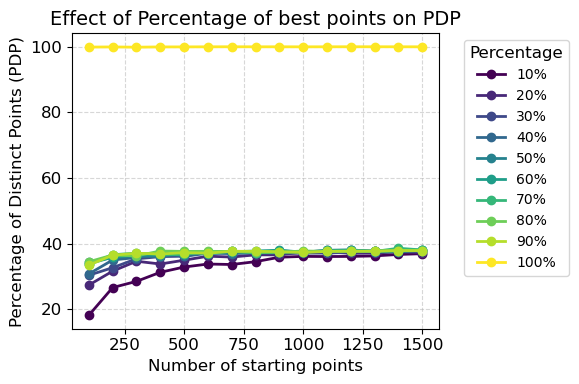

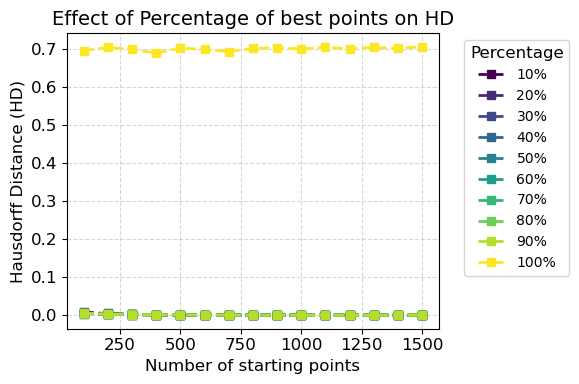

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data
points = np.arange(100, 1600, 100)
keys = sorted(res.keys())  # ensures percentages are in order

# Publication-style settings
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 14,
    "legend.fontsize": 10,
    "lines.linewidth": 2,
    "lines.markersize": 6
})

# Choose a good perceptual colormap
# colors = plt.cm.viridis(np.linspace(0, 1, len(keys)))
colors = [
    '#1b9e77',  # greenish
    '#d95f02',  # orange
    '#7570b3',  # purple
    '#e7298a',  # pink/magenta
    '#66a61e',  # lime green
    '#e6ab02',  # yellow-orange
    '#a6761d',  # brown
    '#666666',  # gray
    '#1f78b4',  # blue
    '#b15928',  # reddish brown
]

# ---- PDP Plot ----
fig, ax = plt.subplots(figsize=(6,4))
for i, p in enumerate(keys):
    ax.plot(points, res[p]["pdp"], marker='o', linestyle='-', color=colors[i], label=f'{p}%')
ax.set_xlabel('Number of starting points')
ax.set_ylabel('Percentage of Distinct Points (PDP)')
ax.set_title('Effect of Percentage of best points on PDP')
ax.grid(True, linestyle='--', alpha=0.5)

# Adaptive legend: outside if many lines, inside if few
if len(keys) > 6:
    ax.legend(title='Percentage', bbox_to_anchor=(1.05, 1), loc='upper left')
else:
    ax.legend(title='Percentage', loc='best')

plt.tight_layout()
plt.savefig("Ex4PDP_vs_p.png", dpi=300, bbox_inches='tight')
plt.show()

# ---- HD Plot ----
fig, ax = plt.subplots(figsize=(6,4))
for i, p in enumerate(keys):
    ax.plot(points, res[p]["hd"], marker='s', linestyle='--', color=colors[i], label=f'{p}%')
ax.set_xlabel('Number of starting points')
ax.set_ylabel('Hausdorff Distance (HD)')
ax.set_title('Effect of Percentage of best points on HD')
ax.grid(True, linestyle='--', alpha=0.5)

# Adaptive legend
if len(keys) > 6:
    ax.legend(title='Percentage', bbox_to_anchor=(1.05, 1), loc='upper left')
else:
    ax.legend(title='Percentage', loc='best')

plt.tight_layout()
plt.savefig("Ex4HD_vs_p.png", dpi=300, bbox_inches='tight')
plt.show()

In [11]:
# for (p,h,acc) in zip(pdpeia,hdeia, accuracyeia):
#     print(p, " * ", h, " * ", acc)